In [97]:
!pip install rocketpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [98]:
from rocketpy import Environment, Flight, Function, Rocket, SolidMotor
import datetime
import pandas as pd
import numpy as np
from rocketpy import SolidMotor
from rocketpy import Rocket

In [99]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [100]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [101]:
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))

In [102]:
# GFS  Global Forecast System
env.set_atmospheric_model(type="Forecast", file="GFS")


Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  78.872 km (ASL): 9.5485 m/s²


Launch Site Details

Launch Date: 2026-06-26 12:00:00 UTC
Launch Site Latitude: -21.94305°
Launch Site Longitude: -48.95409°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91457.82 W    7568202.63 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 475.6 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 78.872 km
Forecast Time Period: from 2026-06-19 00:00:00 to 2026-07-11 18:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From 90.0° to -90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 2.03 m/s
Surface Wind Direction: 79.61°
Surface Wind Heading: 259.61°
Surface Pressure: 96794.27 hPa
Surface Temperature: 290.30 K
Surface Air Density: 116.152 kg/m³
Surface Speed of Sound: 341.56 m/s


Earth Model Details

Earth Radius at Launc

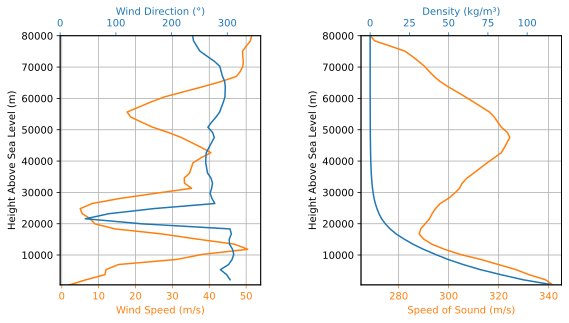

In [103]:
env.info()

In [104]:
# Read the motor CSV file
motor_data = pd.read_csv("motor_data.csv")

# Print column names to diagnose
print("DataFrame columns:", motor_data.columns)

# Drop the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in motor_data.columns:
    motor_data = motor_data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
    print("Updated DataFrame columns:", motor_data.columns)

# Check for duplicate time values in the first column and remove them
if motor_data.iloc[:, 0].duplicated().any():
    print("Duplicate time values found in the thrust curve data. Removing duplicates.")
    motor_data = motor_data.drop_duplicates(subset=[motor_data.columns[0]])

# Select only the 'Time(s)' and 'Thrust(N)' columns and get the values as a NumPy array
thrust_source_array = motor_data[['Time(s)', 'Thrust(N)']].values

# Now, use the NumPy array as the thrust source to initialize SolidMotor
SRmotor = SolidMotor(
    thrust_source=thrust_source_array, # Use the NumPy array
    dry_mass= 0.85601,
    dry_inertia=(0.00001932937824, 0.00001932937909, 0.00000038491070),
    nozzle_radius=0.014885,
    grain_number=2,
    grain_density=1750,
    grain_outer_radius=0.022,
    grain_initial_inner_radius=0.0075,
    grain_initial_height=0.175,
    grain_separation=0,
    grains_center_of_mass_position=0.2,
    center_of_dry_mass_position=0.24,
    nozzle_position=0,
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=0.0070,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

print("SolidMotor initialized successfully!")

DataFrame columns: Index(['Time(s)', 'Thrust(N)'], dtype='str')
SolidMotor initialized successfully!


Nozzle Details
Nozzle Radius: 0.014885 m
Nozzle Throat Radius: 0.007 m

Grain Details
Number of Grains: 2
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.022 m
Grain Inner Radius: 0.0075 m
Grain Height: 0.175 m
Grain Volume: 0.000 m3
Grain Mass: 0.412 kg

Motor Details
Total Burning Time: 2.6259999999999764 s
Total Propellant Mass: 0.823 kg
Structural Mass Ratio: 0.510
Average Propellant Exhaust Velocity: 966.355 m/s
Average Thrust: 302.892 N
Maximum Thrust: 628.31248884 N at 0.9089999999999918 s after ignition.
Total Impulse: 795.395 Ns



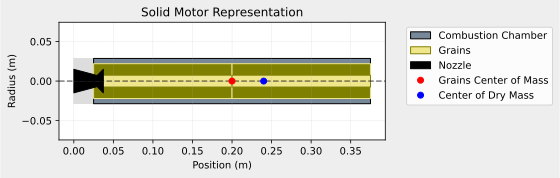

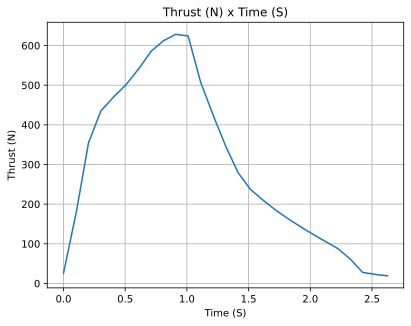

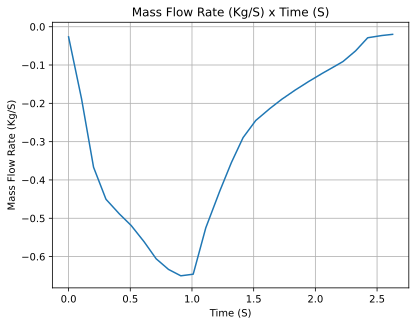

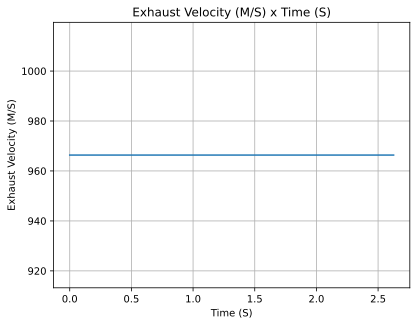

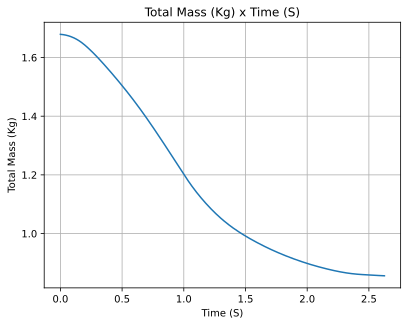

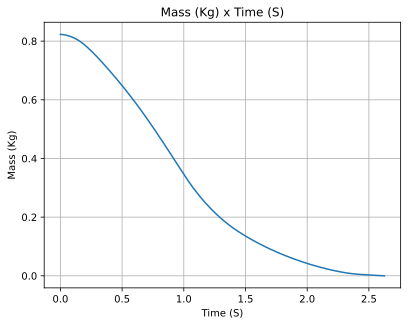

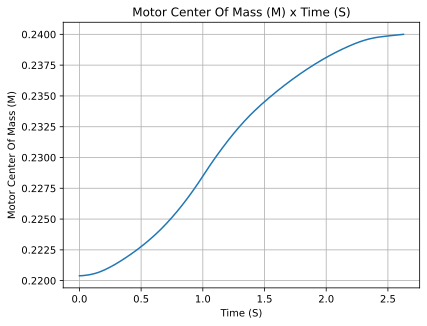

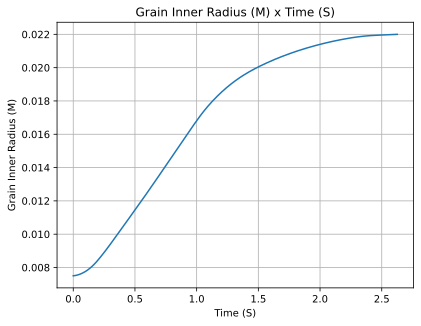

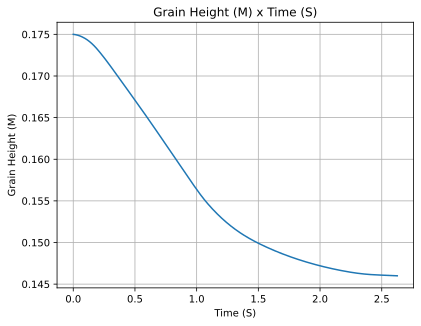

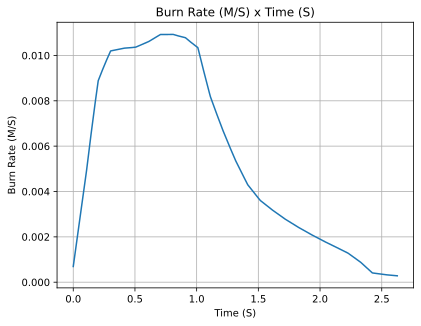

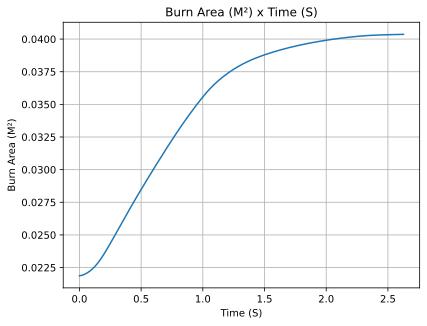

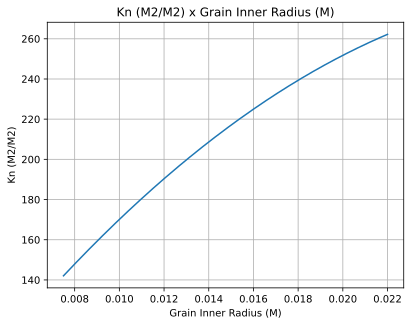

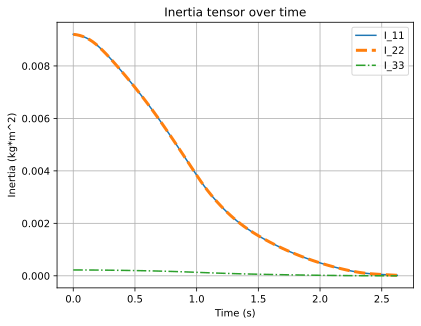

In [105]:
SRmotor.all_info()

In [106]:
# Function to read and process drag curve CSVs
def load_drag_curve(filepath):
    # Read the CSV with semicolon delimiter, comma decimal
    drag_data = pd.read_csv(filepath, delimiter=';', skipinitialspace=True, header=None, decimal=',')

    # Drop any columns that are entirely NaN (due to extra semicolons)
    drag_data.dropna(axis=1, how='all', inplace=True)

    # Ensure there are at least two columns
    if drag_data.shape[1] < 2:
        raise ValueError(f"Drag curve file {filepath} does not contain enough columns (expected at least 2).")

    # Convert the relevant columns to numeric, coercing errors
    for col in drag_data.columns:
        drag_data[col] = pd.to_numeric(drag_data[col], errors='coerce')

    # Drop rows with NaN values that resulted from coercion
    drag_data.dropna(inplace=True)

    # Sort by Mach number (first column) and remove duplicates
    drag_data = drag_data.sort_values(drag_data.columns[0]).drop_duplicates(drag_data.columns[0])

    # Return a RocketPy Function object (required by Rocket)
    return Function(
        drag_data.values.tolist(),
        inputs=["Mach"],
        outputs=["Drag Coefficient"],
        extrapolation="linear",
    )

# Load and process drag curve data
power_off_drag = load_drag_curve("poweroffdragcurve.csv")
power_on_drag = load_drag_curve("powerondragcurve.csv")


SRrocket = Rocket(
    radius = 0.038,
    mass=3.275,
    inertia=(0.723, 0.723, 0.002),
    power_off_drag=power_off_drag,
    power_on_drag=power_on_drag,
    center_of_mass_without_motor=0.735,
    coordinate_system_orientation="nose_to_tail",
)

print("Rocket object created successfully!")

Rocket object created successfully!


/home/vinicius/Documentos/projects/flight-simulations/.venv/lib64/python3.14/site-packages/rocketpy/mathutils/function.py:4131: UserWarning: Extrapolation method set to 'constant' because the linear method is not supported.
  warnings.warn(
/home/vinicius/Documentos/projects/flight-simulations/.venv/lib64/python3.14/site-packages/rocketpy/mathutils/function.py:4131: UserWarning: Extrapolation method set to 'constant' because the linear method is not supported.
  warnings.warn(


In [107]:
SRrocket.add_motor(SRmotor, position=1.5)

In [108]:
nose_cone = SRrocket.add_nose(
    length=0.197, kind="Ogive", position=0
)

aletas = SRrocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.10,
    tip_chord=0.047,
    span=0.057,
    position=1.395,
    cant_angle=58.99,
)



In [109]:
# main = SRrocket.add_parachute(
#     name="main",
#     cd_s=1.5,
#     trigger=750,      # ejection altitude in meters
#     sampling_rate=10,
#     lag=1.5,
#     radius=0.6,
#     noise=(0, 8.3, 0.5),
# )

In [110]:
rail_buttons = SRrocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)

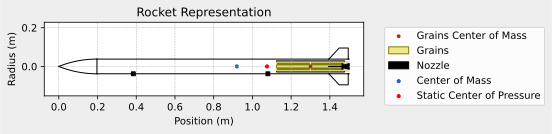

In [111]:
SRrocket.draw()

In [112]:
SRrocket.info()


Inertia Details

Rocket Mass: 3.275 kg (without motor)
Rocket Dry Mass: 4.131 kg (with unloaded motor)
Rocket Loaded Mass: 4.954 kg
Rocket Structural Mass Ratio: 0.834
Rocket Inertia (with unloaded motor) 11: 0.910 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.910 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.002 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.038 m
Rocket Frontal Area: 0.004536 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.109 m
Rocket Center of Dry Mass - Nozzle Exit: 0.656 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.456 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.076 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 5.441/rad

Center of Pressure

Nose Co

In [113]:
test_flight = Flight(
    rocket=SRrocket, environment=env, rail_length=4, inclination=85, heading=0,
    terminate_on_apogee=False, verbose=True,
)

KeyboardInterrupt: 

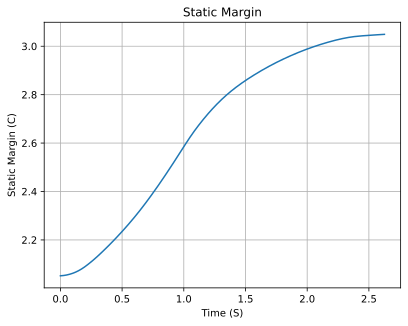

In [ ]:
SRrocket.plots.static_margin()

In [ ]:
test_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 475.58 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.052 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.40 m/s
Lateral Surface Wind Speed: 1.98 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.407 s
Rail Departure Velocity: 19.932 m/s
Rail Departure Stability Margin: 2.186 c
Rail Departure Angle of Attack: 5.796°
Rail Departure Thrust-Weight Ratio: 9.946
Rail Departure Reynolds Number: 9.843e+06


Burn out State

Burn out time: 2.626 s
Altitude at burn out: 564.725 m (ASL) | 89.150 m (AGL)
Rocket speed at burn out: 19.172 m/s
Freestream velocity a

In [ ]:
test_flight.plots

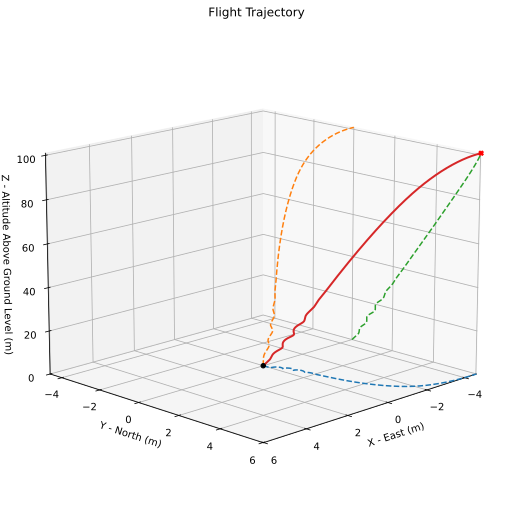

In [ ]:
test_flight.plots.trajectory_3d()

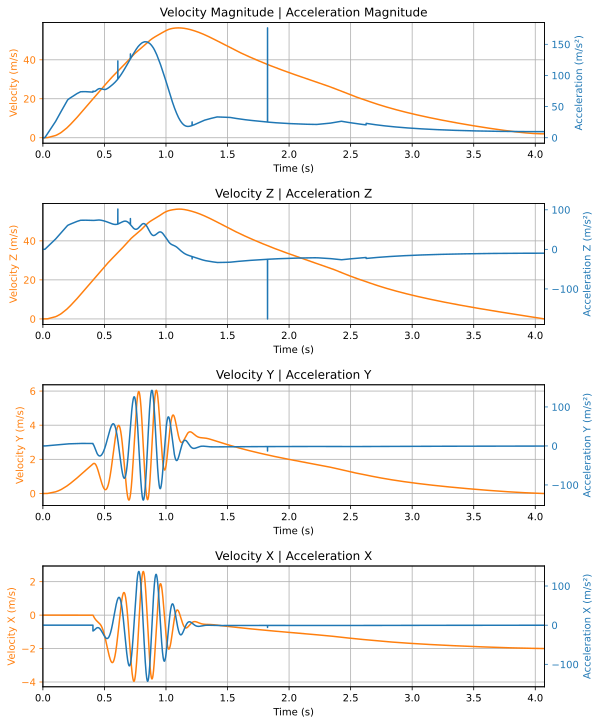

In [ ]:
test_flight.plots.linear_kinematics_data()

In [ ]:
test_flight.prints.apogee_conditions()


Apogee State

Apogee Time: 4.074 s
Apogee Altitude: 576.527 m (ASL) | 100.951 m (AGL)
Apogee Freestream Speed: 0.746 m/s
Apogee X position: -4.625 m
Apogee Y position: 6.024 m
Apogee latitude: -21.9429987°
Apogee longitude: -48.9541309°


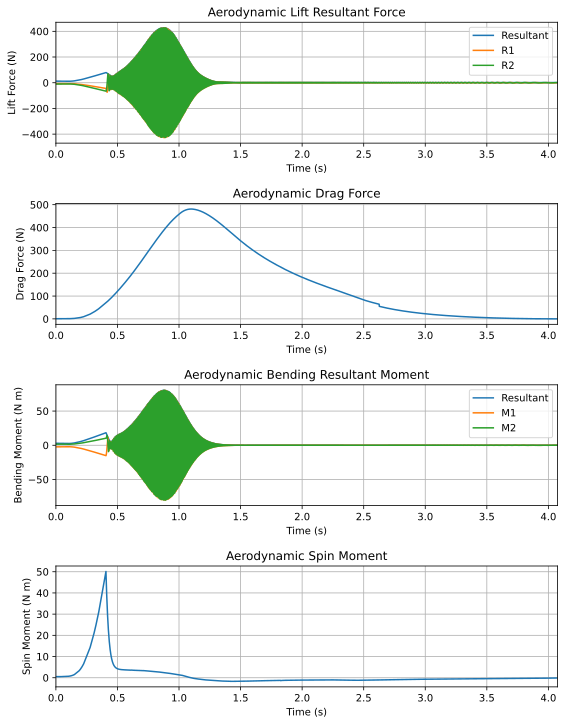

In [ ]:
test_flight.plots.aerodynamic_forces()

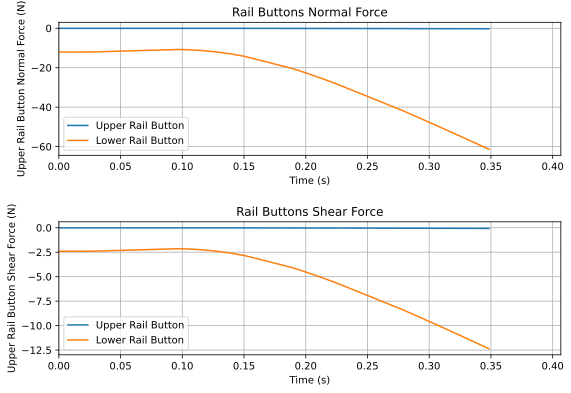

In [ ]:
test_flight.plots.rail_buttons_forces()